In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
class CustomDataset:

    def __init__(self, root):

        self.samples = []

        classes = sorted(os.listdir(root))

        for label in classes:

            folder = os.path.join(root, label)

            for image_name in os.listdir(folder):

                image_path = os.path.join(folder, image_name)

                self.samples.append(
                    (image_path, int(label))
                )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("L")

        image = np.array(image, dtype=np.float32)

        # Normalization
        image = (image - 127.5) / 127.5

        image = torch.tensor(image).unsqueeze(0)

        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [3]:
class CustomDataLoader:

    def __init__(self, dataset, batch_size=32, shuffle=True):

        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indices = list(range(len(dataset)))

    def __len__(self):

        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def __iter__(self):

        if self.shuffle:
            random.shuffle(self.indices)

        self.current = 0

        return self

    def __next__(self):

        if self.current >= len(self.indices):
            raise StopIteration

        batch_indices = self.indices[
            self.current:self.current+self.batch_size
        ]

        images = []
        labels = []

        for idx in batch_indices:

            image, label = self.dataset[idx]

            images.append(image)
            labels.append(label)

        self.current += self.batch_size

        images = torch.stack(images)

        labels = torch.tensor(labels)

        return images, labels

In [4]:
train_dataset = CustomDataset("MNIST/train")
test_dataset = CustomDataset("MNIST/test")

trainloader = CustomDataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

testloader = CustomDataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

print("Train Images :", len(train_dataset))
print("Test Images :", len(test_dataset))

images, labels = next(iter(trainloader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Device : cuda
Train Images : 60000
Test Images : 10000
Image Batch Shape : torch.Size([64, 1, 28, 28])
Label Batch Shape : torch.Size([64])


In [5]:
class DeepCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [6]:
model = DeepCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

DeepCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (15): Conv2d(128, 128, kernel_si

In [7]:
images, labels = next(iter(trainloader))

images = images.to(device)

outputs = model(images)

print("Input Shape :", images.shape)

print("Output Shape :", outputs.shape)

Input Shape : torch.Size([64, 1, 28, 28])
Output Shape : torch.Size([64, 10])


In [8]:
def train(model, trainloader, testloader, epochs):

    train_losses = []
    train_accuracies = []

    test_losses = []
    test_accuracies = []

    for epoch in range(epochs):

        # ==========================
        # TRAINING
        # ==========================

        model.train()

        running_loss = 0.0

        correct = 0
        total = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # ==========================
        # TESTING
        # ==========================

        model.eval()

        running_loss = 0.0

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in testloader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

        test_loss = running_loss / len(testloader)
        test_acc = 100 * correct / total

        test_losses.append(test_loss)
        test_accuracies.append(test_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}%"
        )

    return (
        train_losses,
        train_accuracies,
        test_losses,
        test_accuracies
    )

In [10]:
train_loss, train_acc, test_loss, test_acc = train(
    model,
    trainloader,
    testloader,
    epochs=10
)

Epoch [1/10] | Train Loss: 0.1433 | Train Acc: 95.56% | Test Loss: 0.0318 | Test Acc: 99.01%
Epoch [2/10] | Train Loss: 0.0529 | Train Acc: 98.51% | Test Loss: 0.0313 | Test Acc: 99.03%
Epoch [3/10] | Train Loss: 0.0392 | Train Acc: 98.92% | Test Loss: 0.0365 | Test Acc: 99.00%
Epoch [4/10] | Train Loss: 0.0323 | Train Acc: 99.14% | Test Loss: 0.0324 | Test Acc: 99.04%
Epoch [5/10] | Train Loss: 0.0307 | Train Acc: 99.18% | Test Loss: 0.0312 | Test Acc: 99.24%
Epoch [6/10] | Train Loss: 0.0250 | Train Acc: 99.31% | Test Loss: 0.0202 | Test Acc: 99.47%
Epoch [7/10] | Train Loss: 0.0241 | Train Acc: 99.34% | Test Loss: 0.0304 | Test Acc: 99.39%
Epoch [8/10] | Train Loss: 0.0236 | Train Acc: 99.41% | Test Loss: 0.0231 | Test Acc: 99.51%
Epoch [9/10] | Train Loss: 0.0205 | Train Acc: 99.46% | Test Loss: 0.0325 | Test Acc: 99.46%
Epoch [10/10] | Train Loss: 0.0196 | Train Acc: 99.48% | Test Loss: 0.0316 | Test Acc: 99.20%


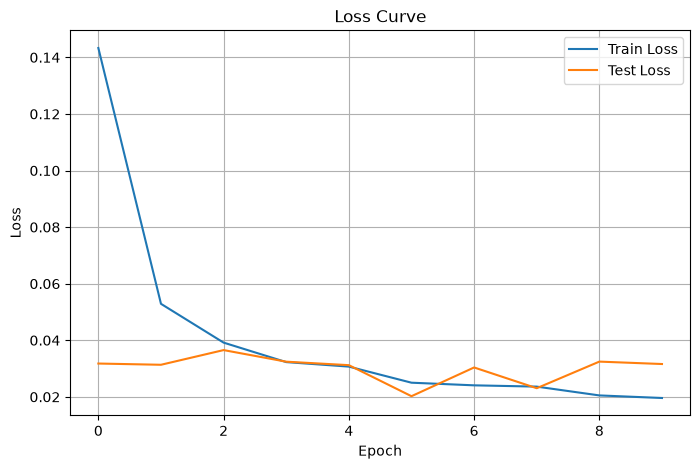

In [11]:
plt.figure(figsize=(8,5))

plt.plot(train_loss,label="Train Loss")

plt.plot(test_loss,label="Test Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.grid(True)

plt.show()

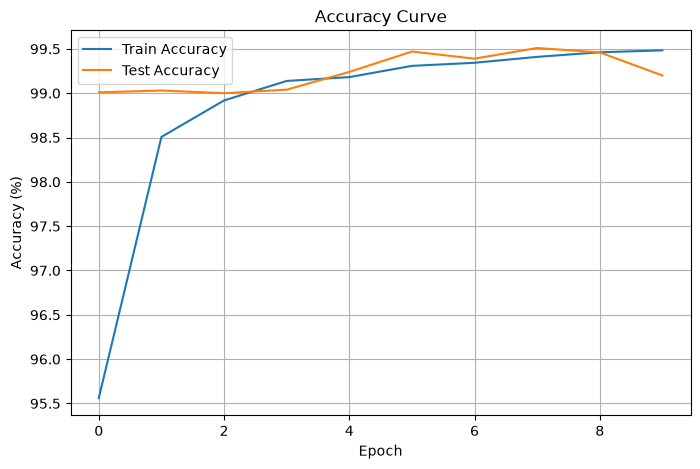

In [12]:
plt.figure(figsize=(8,5))

plt.plot(train_acc,label="Train Accuracy")

plt.plot(test_acc,label="Test Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Accuracy Curve")

plt.legend()

plt.grid(True)

plt.show()